Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2455.44it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



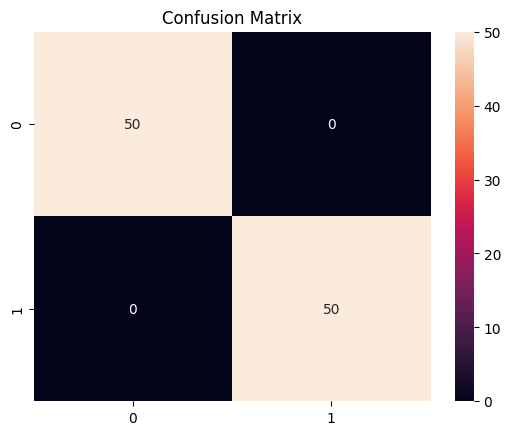

In [5]:
import sys
sys.path.append("../src")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from firewall import analyze_prompt

df = pd.read_csv("../dataset/prompts.csv")

y_true = []
y_pred = []

for prompt, label in zip(df["prompt"], df["label"]):

    score, decision = analyze_prompt(prompt)

    pred = 1 if decision in ["BLOCK","FLAG"] else 0

    y_true.append(label)
    y_pred.append(pred)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True)

plt.title("Confusion Matrix")

plt.show()